# FIT5149 Assessment 1: Final Model Implementation

This notebook contains the reproducible implementation of the final Kaggle model selected by **Group 43**.

**Final model:** CatBoost target-aware sanction-rate regression.

The model predicts the sanction rate for each application, constrains the rate to the valid interval `[0, 1]`, and converts the prediction back to a sanctioned dollar amount using `requested_amount_aud`.

Model comparison, exploratory analysis, feature-influence evidence, and justification for model selection are presented in the assessment report. Code for rejected candidate models has been removed from this final implementation.


In [1]:
# Imports and reproducibility settings
from pathlib import Path
import os
import platform
import sys
import time

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import catboost

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor

RANDOM_STATE = 42
N_SPLITS = 5
TARGET = "sanctioned_amount_aud"

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def rmse(actual, predicted):
    return mean_squared_error(actual, predicted) ** 0.5


## 1. Load the supplied data

The three input CSVs stay in the repository root, one folder above this development notebook. This older implementation is kept for reference, not as the current final model.


In [2]:
DATA_DIR = Path.cwd()

if not (DATA_DIR / "training_set.csv").exists():
    candidate = Path.cwd().parent
    if (candidate / "training_set.csv").exists():
        DATA_DIR = candidate

train = pd.read_csv(DATA_DIR / "training_set.csv")
test = pd.read_csv(DATA_DIR / "kaggle_test_X.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(f"Training data: {train.shape[0]:,} rows x {train.shape[1]} columns")
print(f"Kaggle test:   {test.shape[0]:,} rows x {test.shape[1]} columns")
print(f"Submission:    {sample_submission.shape[0]:,} rows x {sample_submission.shape[1]} columns")


Training data: 19,322 rows x 29 columns
Kaggle test:   10,000 rows x 28 columns
Submission:    10,000 rows x 2 columns


## 2. File and schema integrity checks

These checks fail early if the supplied competition files do not match the expected schema or row identifiers.


In [3]:
expected_train_shape = (19_322, 29)
expected_test_shape = (10_000, 28)

assert train.shape == expected_train_shape
assert test.shape == expected_test_shape
assert TARGET in train.columns and TARGET not in test.columns
assert train.drop(columns=TARGET).columns.tolist() == test.columns.tolist()
assert train["application_id"].is_unique
assert test["application_id"].is_unique
assert test["application_id"].equals(sample_submission["application_id"])
assert sample_submission.columns.tolist() == ["application_id", TARGET]
assert train["application_id"].str.fullmatch(r"LN-\d{6}").all()
assert test["application_id"].str.fullmatch(r"LN-\d{6}").all()

train_dates = pd.to_datetime(
    train["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)
test_dates = pd.to_datetime(
    test["application_date"],
    format="%d/%m/%Y",
    errors="raise",
)

integrity_checks = pd.Series({
    "training_rows": len(train),
    "test_rows": len(test),
    "duplicate_training_rows": int(train.duplicated().sum()),
    "duplicate_test_rows": int(test.duplicated().sum()),
    "duplicate_training_ids": int(train["application_id"].duplicated().sum()),
    "duplicate_test_ids": int(test["application_id"].duplicated().sum()),
    "shared_ids_between_train_and_test": int(
        train["application_id"].isin(test["application_id"]).sum()
    ),
    "training_date_min": train_dates.min().date(),
    "training_date_max": train_dates.max().date(),
    "test_date_min": test_dates.min().date(),
    "test_date_max": test_dates.max().date(),
})

print("All schema and identifier checks passed.")
display(integrity_checks)


All schema and identifier checks passed.


training_rows                             19322
test_rows                                 10000
duplicate_training_rows                       0
duplicate_test_rows                           0
duplicate_training_ids                        0
duplicate_test_ids                            0
shared_ids_between_train_and_test             0
training_date_min                    2023-01-01
training_date_max                    2024-12-30
test_date_min                        2023-01-01
test_date_max                        2024-12-30
dtype: object

## 3. Target-aware formulation

Development analysis showed that sanctioned amounts follow a small set of sanction rates relative to the requested amount. The selected model therefore predicts sanction rate and converts the prediction back to a dollar amount using `requested_amount_aud`.

The sanction-rate tiers are used to construct balanced validation folds, but are never supplied to the model as predictor variables.


In [4]:
y = train[TARGET].copy()
requested = train["requested_amount_aud"]
requested_array = requested.to_numpy()

assert (requested > 0).all()

sanction_rate = (y / requested).round(2).astype(float)

target_checks = pd.Series({
    "zero_target_n": int((y == 0).sum()),
    "zero_target_pct": 100 * (y == 0).mean(),
    "sanction_above_request_n": int((y > requested).sum()),
    "unique_rounded_sanction_rates": sorted(sanction_rate.unique().tolist()),
})

display(target_checks)


zero_target_n                                                           5177
zero_target_pct                                                       26.793
sanction_above_request_n                                                   0
unique_rounded_sanction_rates    [0.0, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
dtype: object

## 4. Final cleaning and feature engineering

The same deterministic transformations are applied to the labelled and Kaggle-test data. Confirmed sentinel codes are converted to missing values, informative missingness indicators are retained, calendar and lending-related features are created, and fields excluded during development are removed before modelling.


In [5]:
SENTINEL_COLUMNS = [
    "existing_repayments_aud",
    "has_co_applicant",
    "property_value_aud",
]

MISSING_INDICATOR_COLUMNS = [
    column
    for column in train.drop(columns=TARGET).columns
    if train[column].isna().any() or column in SENTINEL_COLUMNS
]

def engineer_features(frame):
    x = frame.copy()

    # Convert confirmed encoded missing values.
    for column in SENTINEL_COLUMNS:
        x[column] = x[column].replace(-999, np.nan)

    # Preserve missingness information.
    x["missing_value_count"] = x.isna().sum(axis=1)

    for column in MISSING_INDICATOR_COLUMNS:
        x[f"{column}_is_missing"] = x[column].isna().astype("int8")

    # Calendar features.
    application_date = pd.to_datetime(
        x.pop("application_date"),
        format="%d/%m/%Y",
        errors="raise",
    )

    x["application_year"] = application_date.dt.year
    x["application_month_sin"] = np.sin(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_month_cos"] = np.cos(
        2 * np.pi * application_date.dt.month / 12
    )
    x["application_dayofyear_sin"] = np.sin(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )
    x["application_dayofyear_cos"] = np.cos(
        2 * np.pi * application_date.dt.dayofyear / 365.25
    )

    # Reconcile annual and monthly income.
    income_candidates = pd.concat(
        [
            x["annual_income_aud"],
            12 * x["monthly_income_aud"],
        ],
        axis=1,
    )

    x["annual_income_reconciled_aud"] = income_candidates.median(
        axis=1,
        skipna=True,
    )
    x["income_sources_available"] = income_candidates.notna().sum(axis=1)

    x["income_relative_gap"] = (
        (x["annual_income_aud"] - 12 * x["monthly_income_aud"]).abs()
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    # Lending-related ratios.
    x["requested_to_property_value"] = (
        x["requested_amount_aud"]
        / x["property_value_aud"].replace(0, np.nan)
    )

    x["requested_to_annual_income"] = (
        x["requested_amount_aud"]
        / x["annual_income_reconciled_aud"].replace(0, np.nan)
    )

    x["repayments_to_monthly_income"] = (
        x["existing_repayments_aud"]
        / (x["annual_income_reconciled_aud"] / 12).replace(0, np.nan)
    )

    x["property_value_minus_requested"] = (
        x["property_value_aud"] - x["requested_amount_aud"]
    )

    # Remove the row identifier, corrupted field, and excluded property reference.
    x = x.drop(
        columns=[
            "application_id",
            "property_age_years",
            "property_ref",
        ]
    )

    return x

X_selected = engineer_features(train.drop(columns=TARGET))
X_kaggle_selected = engineer_features(test)

assert X_selected.columns.tolist() == X_kaggle_selected.columns.tolist()
assert not np.isinf(
    X_selected.select_dtypes(include="number").to_numpy()
).any()

selected_categorical_features = (
    X_selected
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

# CatBoost categorical values are converted to explicit strings.
for column in selected_categorical_features:
    X_selected[column] = (
        X_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

    X_kaggle_selected[column] = (
        X_kaggle_selected[column]
        .astype("string")
        .fillna("__MISSING__")
        .astype(str)
    )

print(f"Final predictor count: {X_selected.shape[1]}")
print(f"Categorical predictors: {len(selected_categorical_features)}")


Final predictor count: 49
Categorical predictors: 12


## 5. Validation design

A fixed five-fold `StratifiedKFold` split is used for reproducible model validation. Stratification is based only on the observed sanction-rate tier so that each fold contains a similar target composition.


In [6]:
strata = sanction_rate.map(lambda value: f"{value:.2f}")

splitter = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

folds = list(
    splitter.split(
        X_selected,
        strata,
    )
)

fold_balance = []

for fold_number, (_, valid_index) in enumerate(folds, start=1):
    counts = (
        strata.iloc[valid_index]
        .value_counts(normalize=True)
        .sort_index()
    )
    fold_balance.append(
        counts.rename(f"fold_{fold_number}")
    )

display(
    pd.concat(fold_balance, axis=1)
    .T
    .style
    .format("{:.2%}")
)


,0.00,0.65,0.70,0.75,0.80,0.85,0.90,1.00
fold_1,26.78%,16.84%,29.44%,13.30%,12.94%,0.23%,0.26%,0.21%
fold_2,26.80%,16.87%,29.42%,13.27%,12.94%,0.23%,0.26%,0.21%
fold_3,26.81%,16.87%,29.43%,13.28%,12.94%,0.21%,0.26%,0.21%
fold_4,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%
fold_5,26.79%,16.85%,29.43%,13.30%,12.97%,0.21%,0.26%,0.21%


## 6. Five-fold validation of the final CatBoost model

The selected CatBoost model predicts sanction rate directly. Validation predictions are converted back to sanctioned dollar amounts before RMSE and MAE are calculated.


In [7]:
catboost_rows = []
catboost_oof = np.full(len(train), np.nan)

started = time.time()

for fold_number, (train_index, valid_index) in enumerate(folds, start=1):

    model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.03,
        depth=7,
        loss_function="RMSE",
        l2_leaf_reg=5.0,
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )

    model.fit(
        X_selected.iloc[train_index],
        sanction_rate.iloc[train_index],
        cat_features=selected_categorical_features,
    )

    predicted_rate = np.clip(
        model.predict(X_selected.iloc[valid_index]),
        0,
        1,
    )

    predicted_amount = np.clip(
        predicted_rate * requested_array[valid_index],
        0,
        requested_array[valid_index],
    )

    catboost_oof[valid_index] = predicted_amount

    fold_rmse = rmse(
        y.iloc[valid_index],
        predicted_amount,
    )

    fold_mae = mean_absolute_error(
        y.iloc[valid_index],
        predicted_amount,
    )

    catboost_rows.append({
        "fold": fold_number,
        "rmse_aud": fold_rmse,
        "mae_aud": fold_mae,
    })

    print(
        f"Fold {fold_number}: "
        f"RMSE ${fold_rmse:,.0f} | "
        f"MAE ${fold_mae:,.0f}"
    )

catboost_validation_detail = pd.DataFrame(catboost_rows)

catboost_validation_summary = pd.Series({
    "mean_fold_rmse_aud":
        catboost_validation_detail["rmse_aud"].mean(),
    "sd_fold_rmse_aud":
        catboost_validation_detail["rmse_aud"].std(),
    "mean_fold_mae_aud":
        catboost_validation_detail["mae_aud"].mean(),
    "global_oof_rmse_aud":
        rmse(y, catboost_oof),
    "validation_seconds":
        time.time() - started,
})

display(catboost_validation_summary)


Fold 1: RMSE $32,581 | MAE $16,474
Fold 2: RMSE $34,578 | MAE $17,384
Fold 3: RMSE $35,096 | MAE $17,714
Fold 4: RMSE $33,019 | MAE $16,899
Fold 5: RMSE $35,225 | MAE $17,865


mean_fold_rmse_aud    34,099.758
sd_fold_rmse_aud       1,220.932
mean_fold_mae_aud     17,267.309
global_oof_rmse_aud   34,117.186
validation_seconds        43.272
dtype: float64

### Validation stability

The figure below is included only as a compact visual check of fold-to-fold stability for the final model.


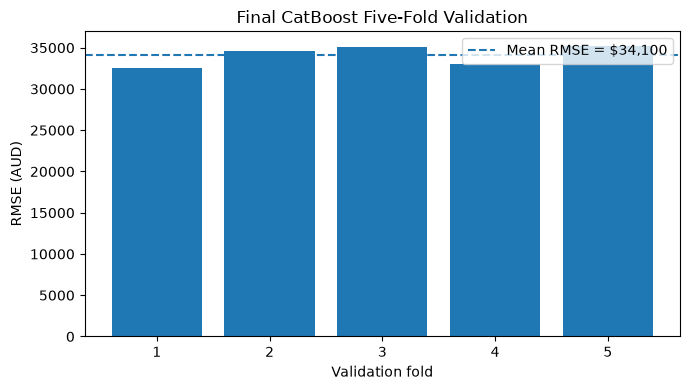

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    catboost_validation_detail["fold"].astype(str),
    catboost_validation_detail["rmse_aud"],
)

mean_rmse = catboost_validation_detail["rmse_aud"].mean()

ax.axhline(
    mean_rmse,
    linestyle="--",
    label=f"Mean RMSE = ${mean_rmse:,.0f}",
)

ax.set_xlabel("Validation fold")
ax.set_ylabel("RMSE (AUD)")
ax.set_title("Final CatBoost Five-Fold Validation")
ax.legend()

plt.tight_layout()
plt.show()


## 7. Final training and Kaggle prediction

Following validation, the selected CatBoost model is retrained using all labelled observations. Predicted sanction rates are constrained to `[0, 1]`, converted back to dollar amounts, and saved in the required Kaggle format as `submission.csv`.


In [9]:
started = time.time()

catboost_final_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    l2_leaf_reg=5.0,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

catboost_final_model.fit(
    X_selected,
    sanction_rate,
    cat_features=selected_categorical_features,
)

predicted_rate = np.clip(
    catboost_final_model.predict(X_kaggle_selected),
    0,
    1,
)

requested_test = test["requested_amount_aud"].to_numpy()

final_prediction = np.clip(
    predicted_rate * requested_test,
    0,
    requested_test,
).round(2)

submission = sample_submission[["application_id"]].copy()
submission[TARGET] = final_prediction

submission_path = DATA_DIR / "submissions" / "reproduced_catboost_clean.csv"
submission.to_csv(submission_path, index=False)

# Submission-format and logical checks.
assert submission.columns.tolist() == sample_submission.columns.tolist()
assert len(submission) == len(test) == 10_000
assert submission["application_id"].equals(test["application_id"])
assert submission["application_id"].is_unique
assert np.isfinite(submission[TARGET]).all()
assert (submission[TARGET] >= 0).all()
assert (submission[TARGET] <= test["requested_amount_aud"]).all()

submission_checks = pd.Series({
    "file": submission_path.name,
    "cv_rmse_aud":
        catboost_validation_detail["rmse_aud"].mean(),
    "rows": len(submission),
    "unique_application_ids":
        submission["application_id"].nunique(),
    "missing_predictions":
        int(submission[TARGET].isna().sum()),
    "minimum_prediction_aud":
        submission[TARGET].min(),
    "maximum_prediction_aud":
        submission[TARGET].max(),
    "training_seconds":
        time.time() - started,
})

display(submission_checks)
display(submission.head())


file                      reproduced_catboost_clean.csv
cv_rmse_aud                                  34,099.758
rows                                              10000
unique_application_ids                            10000
missing_predictions                                   0
minimum_prediction_aud                            0.000
maximum_prediction_aud                      579,071.330
training_seconds                                 10.191
dtype: object

,application_id,sanctioned_amount_aud
0,LN-029039,"67,069.070"
1,LN-006880,"30,905.990"
2,LN-000529,"102,376.810"
3,LN-002049,"175,035.250"
4,LN-000921,0.000


## 8. Reproducibility information

The package versions and fixed modelling settings below document the environment required to reproduce the final submission.


In [10]:
versions = pd.Series({
    "Python": sys.version.split()[0],
    "Platform": platform.platform(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "CatBoost": catboost.__version__,
    "random_seed": RANDOM_STATE,
    "validation_folds": N_SPLITS,
    "final_output": "submission.csv",
})

display(versions)


Python                                   3.11.15
Platform            macOS-26.6.2-arm64-arm-64bit
NumPy                                      2.4.6
pandas                                     3.0.5
scikit-learn                               1.9.0
CatBoost                                  1.2.10
random_seed                                   42
validation_folds                               5
final_output                      submission.csv
dtype: object